In [107]:
import numpy as np
import matplotlib.pyplot as plt
import pyroomacoustics as pra
import torch
import torchaudio
import torchaudio.transforms
import random
from itertools import combinations

In [108]:
SR = 16000

In [109]:
def random_room_dimensions():
    x = random.uniform(4, 10)
    y = random.uniform(4, 10)
    z = random.uniform(2.5, 5)
    return np.array([x, y, z])

def random_head_position(room_dim, rdtw=0.125):
    rdx, rdy, _ = room_dim
    x = random.uniform(rdtw*rdx, (1-rdtw)*rdx)
    y = random.uniform(rdtw*rdy, (1-rdtw)*rdy)
    z = random.uniform(1, 1.75)
    return np.array([x, y, z])

def random_head_angle():
    return random.uniform(0, 2*np.pi)

def random_mouth_position(head_pos, head_ang):
    hpx, hpy, hpz = head_pos
    rdx = random.uniform(-0.01, 0.01)
    rdy = random.uniform(0.11, 0.15)
    rdz = random.uniform(-0.04, -0.02)
    x = hpx + rdx*np.cos(head_ang) - rdy*np.sin(head_ang)
    y = hpy + rdx*np.sin(head_ang) + rdy*np.cos(head_ang)
    z = hpz + rdz
    return np.array([x, y, z])

def random_ears_position(head_pos, head_ang):
    hpx, hpy, hpz = head_pos
    rdx = random.uniform(0.08, 0.09)
    ear_center_l = np.array([hpx - rdx*np.cos(head_ang), hpy - rdx*np.sin(head_ang), hpz])
    ear_center_r = np.array([hpx + rdx*np.cos(head_ang), hpy + rdx*np.sin(head_ang), hpz])
    return np.array([ear_center_l, ear_center_r])

def define_mics_position(ears_pos):
    ear_center_l, ear_center_r = ears_pos
    lex, ley, lez = ear_center_l
    rex, rey, rez = ear_center_r
    mic_l_1 = np.array([lex, ley, lez - 0.01])
    # mic_l_2 = np.array([lex, ley, lez + 0.01])    
    mic_r_1 = np.array([rex, rey, rez - 0.01])
    # mic_r_2 = np.array([rex, rey, rez + 0.01])
    return np.array([mic_l_1, mic_r_1])
    # return np.array([mic_l_1, mic_l_2, mic_r_1, mic_r_2])

def random_distractor_position(room_dim, head_pos, rdtw=0.125):
    rdx, rdy, _ = room_dim
    hpx, hpy, _ = head_pos
    angle = random.uniform(0, 2*np.pi)

    dx = np.cos(angle)*1
    if dx > 0:
        x_min = hpx + dx
        x_max = (1-rdtw)*rdx
        if x_min > x_max:
            x_min = rdtw*rdx
            x_max = hpx - dx     
    else:
        x_min = rdtw*rdx
        x_max = hpx + dx
        if x_min > x_max:
            x_min = hpx - dx
            x_max = (1-rdtw)*rdx
    x = random.uniform(x_min, x_max)

    dy = np.sin(angle)*1
    if dy > 0:
        y_min = hpy + dy
        y_max = (1-rdtw)*rdy
        if y_min > y_max:
            y_min = rdtw*rdy
            y_max = hpy - dy
    else:
        y_min = rdtw*rdy
        y_max = hpy + dy
        if y_min > y_max:
            y_min = hpy - dy
            y_max = (1-rdtw)*rdy
    y = random.uniform(y_min, y_max)
    
    z = random.uniform(1, 1.75)
    return np.array([x, y, z])

def random_snr(a=-5, b=5):
    return random.uniform(a, b)

def random_rt60(a=0.0, b=1.0):
    return random.uniform(a, b)


## CREATE ROOM

In [110]:
room_dim = random_room_dimensions()
head_pos = random_head_position(room_dim)
head_ang = random_head_angle()
ears_pos = random_ears_position(head_pos, head_ang)
mics_pos = define_mics_position(ears_pos)
mouth_pos = random_mouth_position(head_pos,  head_ang)
distractor_pos = random_distractor_position(room_dim, head_pos)

In [111]:
v = np.prod(room_dim)
s = 2 * np.sum([l1 * l2 for l1, l2 in combinations(room_dim, 2)])
c = pra.parameters._constants_default['c']
sc = 24

In [112]:
room_dim

array([7.64775629, 9.28446501, 3.37948583])

In [121]:
rt60 = random_rt60(a=v*sc*np.log(10)/(c*s))
e_absorption, max_order = pra.inverse_sabine(rt60, room_dim)
# Anechoic Room
#e_absorption, max_order = 1.0, 0
room = pra.ShoeBox(room_dim, fs=SR, materials=pra.Material(e_absorption), max_order=max_order)    

In [126]:
pra.inverse_sabine??

Signature: pra.inverse_sabine(rt60, room_dim, c=None)
Source:   
def inverse_sabine(rt60, room_dim, c=None):
    """
    Given the desired reverberation time (RT60, i.e. the time for the energy to
    drop by 60 dB), the dimensions of a rectangular room (shoebox), and sound
    speed, computes the energy absorption coefficient and maximum image source
    order needed. The speed of sound used is the package wide default (in
    :py:data:`~pyroomacoustics.parameters.constants`).

    Parameters
    ----------
    rt60: float
        desired RT60 (time it takes to go from full amplitude to 60 db decay) in seconds
    room_dim: list of floats
        list of length 2 or 3 of the room side lengths
    c: float
        speed of sound

    Returns
    -------
    absorption: float
        the energy absorption coefficient to be passed to room constructor
    max_order: int
        the maximum image source order necessary to achieve the desired RT60
    """

    if c is None:
        c = cons

In [114]:
# x = np.zeros(1000)

# for i in range(1000):
#     room_dim = random_room_dimensions()
#     head_pos = random_head_position(room_dim, rdtw=0.125)
#     distractor_pos = random_distractor_position(room_dim, head_pos)
#     norm = np.linalg.norm(head_pos - distractor_pos)
#     x[i] = norm

# x.mean()

## LOAD AUDIO

In [115]:
clean_wav = torchaudio.utils.download_asset("tutorial-assets/mvdr/clean_speech.wav")
noise_wav = torchaudio.utils.download_asset("tutorial-assets/mvdr/noise.wav")
signal_clean, sr_clean = torchaudio.load(clean_wav)
signal_noise, sr_noise = torchaudio.load(noise_wav)
signal_clean = signal_clean[0].numpy()
signal_noise = signal_noise[0].numpy()

# Apply desired SNR
signal_clean = signal_clean / np.max(np.abs(signal_clean))  # Normalize
signal_noise = signal_noise / np.max(np.abs(signal_noise))  # Normalize
snr = 0
signal_noise = signal_noise * np.power(10, snr/20)

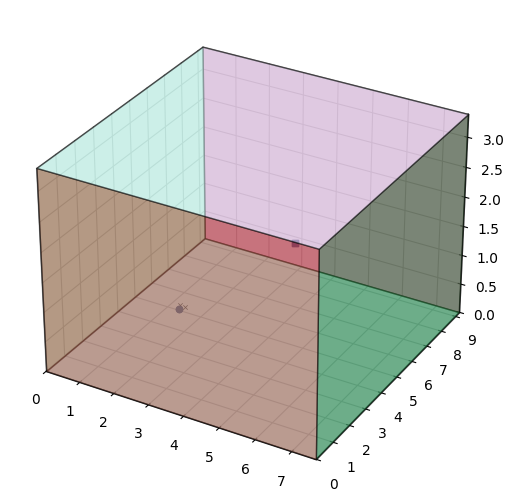

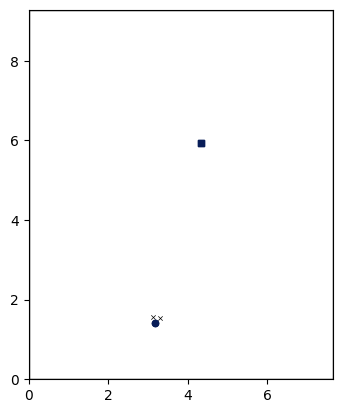

In [116]:
room.add_source(mouth_pos, signal=signal_clean, delay=0.0)
room.add_microphone_array(mics_pos.T)
room.add_source(distractor_pos, signal=signal_noise, delay=0.0)
room.plot();

room2d = pra.ShoeBox(room_dim[0:2], fs=16000)
room2d.add_source(mouth_pos[0:2])
room2d.add_microphone_array(mics_pos.T[0:2])
room2d.add_source(distractor_pos[0:2])
room2d.plot();

## SIMULATE

In [117]:
room.simulate()

In [118]:
mixed_signals = room.mic_array.signals
# Normalize
mixed_signals = mixed_signals / np.max(np.abs(mixed_signals))

In [119]:
mix = torch.from_numpy(mixed_signals).to(torch.float32)

In [120]:
# Save signal
torchaudio.save("out/mixed_SNR-6.wav", mix, SR)